# BWF World Tour Match Outcome Analysis

This notebook analyses men's singles matches from the BWF World Tour between 2018 and 2021.

The core question is whether recent match load before a tournament affects the probability of winning the next match. The workflow moves from raw match data, to feature engineering, to logistic regression models.

## 1. Setup
Import the libraries used for data cleaning, feature engineering, visualisation, and modelling.

In [13]:
# libraries used for data transformation
import ast
import pandas as pd
import numpy as np
from typing import List, Tuple, Dict
from collections import defaultdict

# libraries used for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# libraries used for machine learning
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


# Settings
pd.set_option('display.max_columns', None)

## 2. Load Raw Match Data
Read the source dataset that contains match-level information, scores, rounds, and player identifiers.

In [14]:
#load csv file
df = pd.read_csv(r'data\ms.csv')

### Initial Data Check
Inspect data types, missing values, dataset shape, and a small sample of rows before transforming the data.

In [15]:
print(f"Data Frame dtypes:\n{df.dtypes}")
print(f"Field NA count:\n{df.isna().sum()}")
print(f"Data Frame shape:\n{df.shape}")
print(f"Sample 5 rows:\n{df.head(5)}")

Data Frame dtypes:
tournament                                     str
city                                           str
country                                        str
date                                           str
tournament_type                                str
discipline                                     str
round                                          str
winner                                       int64
nb_sets                                      int64
retired                                       bool
game_1_score                                   str
game_2_score                                   str
game_3_score                                   str
team_one_players                               str
team_two_players                               str
team_one_nationalities                         str
team_two_nationalities                         str
team_one_total_points                        int64
team_two_total_points                        int64
team_one_mos

## 3. Clean and Transform Match Data
Prepare the raw tournament data so it can be used for structured feature engineering and later modelling.

### Add Tournament Round Ranking
Create an ordinal round variable so tournament progress can be compared consistently across event formats.

In [16]:
# Create Tournament round ranking mapping
round_list = df['round'].unique().tolist()
round_list = pd.DataFrame({'round': round_list})
print(f"list of the rounds:{round_list}")

# DELETE Later - drop list to csv to create mapping
#round_list.to_csv(r'data/round_list_for_mapping.csv')

# return every unique tournament round pattern:
unique_rounds = df.groupby('tournament')['round'].unique()
unique_rounds_set = unique_rounds.apply(set)
unique_structures = list(unique_rounds_set)
has_duplicates = len(unique_structures) != len(set(map(frozenset, unique_structures)))
print(f"Is there duplicates in the set?{has_duplicates}")

for structure in set(map(frozenset, unique_structures)):
    print(structure)

# Manually rank rounds for each unique structure
# Define rankings for each unique structure
manual_rankings = {
    frozenset({'Round of 32', 'Qualification round of 16', 'Round of 64', 'Semi final', 'Final', 'Quarter final', 'Round of 16'}): {
        'Final': 1, 'Semi final': 2, 'Quarter final': 3, 'Round of 16': 4, 'Round of 32': 5, 'Round of 64': 6, 'Qualification round of 16': 7
    },
    frozenset({'Round 1', 'Semi final', 'Final', 'Round 3', 'Round 2'}): {
        'Final': 1, 'Semi final': 2, 'Round 3': 3, 'Round 2': 4, 'Round 1': 5
    },
    frozenset({'Round of 32', 'Semi final', 'Round of 64', 'Final', 'Quarter final', 'Round of 16'}): {
        'Final': 1, 'Semi final': 2, 'Quarter final': 3, 'Round of 16': 4, 'Round of 32': 5, 'Round of 64': 6
    },
    frozenset({'Qualification quarter final', 'Round of 32', 'Qualification round of 16', 'Semi final', 'Final', 'Quarter final', 'Round of 16'}): {
        'Final': 1, 'Semi final': 2, 'Quarter final': 3, 'Round of 16': 4, 'Round of 32': 5, 'Qualification quarter final': 6, 'Qualification round of 16': 7
    },
    frozenset({'Round of 32', 'Semi final', 'Final', 'Quarter final', 'Round of 16'}): {
        'Final': 1, 'Semi final': 2, 'Quarter final': 3, 'Round of 16': 4, 'Round of 32': 5
    },
    frozenset({'Qualification round of 16', 'Qualification round of 32', 'Final', 'Round of 32', 'Round of 64', 'Semi final', 'Quarter final', 'Round of 16'}): {
        'Final': 1, 'Semi final': 2, 'Quarter final': 3, 'Round of 16': 4, 'Round of 32': 5, 'Round of 64': 6, 'Qualification round of 16': 7, 'Qualification round of 32': 8
    }
}

# Map rankings back to the tournaments
# Create a mapping of tournaments to their unique round structure rankings
def get_round_rank(row):
    # Find the unique structure for the tournament
    structure = frozenset(unique_rounds[row['tournament']])
    # Get the ranking for the specific round
    return manual_rankings[structure][row['round']]

df['round_rank'] = df.apply(get_round_rank, axis=1)

# Display the results
print(df.shape)
print("DataFrame with Round Rankings:")
df

list of the rounds:                          round
0     Qualification round of 16
1   Qualification quarter final
2                   Round of 32
3                   Round of 16
4                 Quarter final
5                    Semi final
6                         Final
7     Qualification round of 32
8                   Round of 64
9                       Round 1
10                      Round 2
11                      Round 3
Is there duplicates in the set?True
frozenset({'Round 2', 'Round 3', 'Semi final', 'Final', 'Round 1'})
frozenset({'Round of 32', 'Round of 16', 'Quarter final', 'Semi final', 'Final'})
frozenset({'Round of 32', 'Round of 16', 'Round of 64', 'Qualification round of 32', 'Qualification round of 16', 'Quarter final', 'Semi final', 'Final'})
frozenset({'Round of 32', 'Qualification round of 16', 'Round of 16', 'Quarter final', 'Semi final', 'Final', 'Round of 64'})
frozenset({'Round of 32', 'Qualification round of 16', 'Round of 16', 'Quarter final', 'Semi final

,tournament,city,country,date,tournament_type,discipline,round,winner,nb_sets,retired,game_1_score,game_2_score,game_3_score,team_one_players,team_two_players,team_one_nationalities,team_two_nationalities,team_one_total_points,team_two_total_points,team_one_most_consecutive_points,team_two_most_consecutive_points,team_one_game_points,team_two_game_points,team_one_most_consecutive_points_game_1,team_two_most_consecutive_points_game_1,team_one_game_points_game_1,team_two_game_points_game_1,game_1_scores,team_one_most_consecutive_points_game_2,team_two_most_consecutive_points_game_2,team_one_game_points_game_2,team_two_game_points_game_2,game_2_scores,team_one_most_consecutive_points_game_3,team_two_most_consecutive_points_game_3,team_one_game_points_game_3,team_two_game_points_game_3,game_3_scores,round_rank
0,PRINCESS SIRIVANNAVARI Thailand Masters 2018,Bangkok,Thailand,09-01-2018,HSBC BWF World Tour Super 300,MS,Qualification round of 16,1,3,False,11-21,21-18,21-9,Jun Hao Leong,Kantawat Leelavechabutr,MAS,THA,53,48,8,9,5,1,3,9,0,1,"['0-0', '1-0', '2-0', '3-0', '3-1', '4-1', '4-...",4.0,4.0,2.0,0.0,"['0-0', '0-1', '1-1', '1-2', '2-2', '2-3', '3-...",8.0,2.0,3.0,0.0,"['0-0', '1-0', '1-1', '2-1', '3-1', '4-1', '4-...",7
1,PRINCESS SIRIVANNAVARI Thailand Masters 2018,Bangkok,Thailand,09-01-2018,HSBC BWF World Tour Super 300,MS,Qualification round of 16,1,2,False,21-7,21-18,NaN,Teck Zhi Soo,Chico Aura Dwi Wardoyo,MAS,INA,42,25,9,5,3,0,5,1,1,0,"['0-0', '1-0', '2-0', '3-0', '4-0', '4-1', '5-...",6.0,5.0,2.0,0.0,"['0-0', '1-0', '2-0', '3-0', '4-0', '5-0', '6-...",NaN,NaN,NaN,NaN,[],7
2,PRINCESS SIRIVANNAVARI Thailand Masters 2018,Bangkok,Thailand,09-01-2018,HSBC BWF World Tour Super 300,MS,Qualification round of 16,1,3,False,21-16,8-21,23-21,Mek Narongrit,Yee Han Chong,THA,MAS,52,58,4,7,6,1,4,4,2,0,"['0-0', '1-0', '2-0', '2-1', '3-1', '4-1', '5-...",2.0,6.0,0.0,1.0,"['0-0', '0-1', '0-2', '0-3', '1-3', '2-3', '2-...",4.0,7.0,4.0,0.0,"['0-0', '1-0', '2-0', '3-0', '4-0', '4-1', '4-...",7
3,PRINCESS SIRIVANNAVARI Thailand Masters 2018,Bangkok,Thailand,09-01-2018,HSBC BWF World Tour Super 300,MS,Qualification round of 16,1,2,False,21-17,21-7,NaN,Mithun Manjunath,Henrikho Kho Wibowo,IND,INA,42,24,14,4,2,0,5,4,1,0,"['0-0', '0-1', '1-1', '1-2', '2-2', '3-2', '3-...",12.0,3.0,1.0,0.0,"['0-0', '1-0', '2-0', '3-0', '4-0', '5-0', '6-...",NaN,NaN,NaN,NaN,[],7
4,PRINCESS SIRIVANNAVARI Thailand Masters 2018,Bangkok,Thailand,09-01-2018,HSBC BWF World Tour Super 300,MS,Qualification round of 16,2,2,False,13-21,13-21,NaN,Chirag Sen,Hashiru Shimono,IND,JPN,26,42,4,5,0,3,4,5,0,1,"['0-0', '1-0', '2-0', '2-1', '2-2', '2-3', '3-...",3.0,4.0,0.0,2.0,"['0-0', '1-0', '2-0', '3-0', '3-1', '4-1', '4-...",NaN,NaN,NaN,NaN,[],7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3756,Orleans Masters 2021 (New Dates),Orleans,France,26-03-2021,BWF Tour Super 100,MS,Quarter final,2,2,False,11-21,15-21,NaN,Ditlev Jaeger Holm,Hans-Kristian Solberg Vittinghus,DEN,DEN,26,42,4,8,0,7,2,6,0,2,"['0-0', '0-1', '1-1', '1-2', '1-3', '1-4', '1-...",4.0,8.0,0.0,5.0,"['0-0', '1-0', '2-0', '2-1', '3-1', '3-2', '3-...",NaN,NaN,NaN,NaN,[],3
3757,Orleans Masters 2021 (New Dates),Orleans,France,26-03-2021,BWF Tour Super 100,MS,Quarter final,1,2,False,21-14,21-10,NaN,Mads Christophersen,Joran Kweekel,DEN,NED,42,24,8,5,2,0,5,5,1,0,"['0-0', '1-0', '1-1', '2-1', '3-1', '4-1', '4-...",6.0,3.0,1.0,0.0,"['0-0', '1-0', '2-0', '3-0', '3-1', '4-1', '5-...",NaN,NaN,NaN,NaN,[],3
3758,Orleans Masters 2021 (New Dates),Orleans,France,27-03-2021,BWF Tour Super 100,MS,Semi final,1,3,False,21-17,9-21,21-11,Toma Junior Popov,Kunlavut Vitidsarn,FRA,THA,51,49,6,6,4,1,5,4,3,0,"['0-0', '0-1', '0-2', '0-3', '0-4', '1-4', '2-...",4.0,6.0,0.0,1.0,"['0-0', '1-0', '1-1', '1-2', '2-2', '2-3', '2-...",6.0,2.0,1.0,0.0,"['0-0', '1-0', '1-1', '2-1', '3-1', '4-1', '4-...",2
3759,Orleans Masters 2021 (New Dates),Or

### Resolve Retired Matches
Where a retirement leaves the winner unclear, infer the advancing player from the next round and update the match outcome fields.

In [17]:
# Handle the outliers early before df change to cs_df
retired_matches = df[df['winner'] == 0]
print(f"row count for winner == 0 before transformation {retired_matches.shape}")
# If winner = 0 then search for team_one or team_two in next rank of tournament (current round_rank - 1) filter same tournament current round_rank - 1)
# def function to find advancing player from a match with retired players
def find_advancing_player(row, df):
    # Get the tournament and round_rank for the current match
    tournament = row['tournament']
    current_round = row['round_rank']
    
    # Find matches in the next round (round_rank - 1) for the same tournament
    next_round_matches = df[
        (df['tournament'] == tournament) & 
        (df['round_rank'] == current_round - 1)
    ]
    
    # Check which player moved on to the next round
    advancing_player = None
    for _, next_match in next_round_matches.iterrows():
        if row['team_one_players'] in [next_match['team_one_players'], next_match['team_two_players']]:
            advancing_player = row['team_one_players']
        elif row['team_two_players'] in [next_match['team_one_players'], next_match['team_two_players']]:
            advancing_player = row['team_two_players']
    
    return advancing_player

# Step 3: Apply the function to find advancing players for retired matches
retired_matches['advancing_player_name'] = retired_matches.apply(
    lambda row: find_advancing_player(row, df), axis=1
)

# Step 4: Merge the results back into the original DataFrame
df = df.merge(retired_matches[['team_one_players', 'team_two_players', 'round_rank', 'tournament', 'advancing_player_name']],
              on=['team_one_players', 'team_two_players', 'round_rank', 'tournament'], how='left')

# Update the df['winner'] column with advancing_player_name as winner
df['winner'] = df.apply(
    lambda row: 1 if row['team_one_players'] == row['advancing_player_name'] 
    else ( 2 if row['team_two_players'] == row['advancing_player_name'] else row['winner']),
    axis=1)

# Update the df['retired'] column with advancing_player_name != retired
df['retired'] = df.apply(
    lambda row: 2 if row['team_one_players'] == row['advancing_player_name'] 
    else ( 1 if row['team_two_players'] == row['advancing_player_name'] else 0),
    axis=1)

df.sample(5)


row count for winner == 0 before transformation (70, 39)


,tournament,city,country,date,tournament_type,discipline,round,winner,nb_sets,retired,game_1_score,game_2_score,game_3_score,team_one_players,team_two_players,team_one_nationalities,team_two_nationalities,team_one_total_points,team_two_total_points,team_one_most_consecutive_points,team_two_most_consecutive_points,team_one_game_points,team_two_game_points,team_one_most_consecutive_points_game_1,team_two_most_consecutive_points_game_1,team_one_game_points_game_1,team_two_game_points_game_1,game_1_scores,team_one_most_consecutive_points_game_2,team_two_most_consecutive_points_game_2,team_one_game_points_game_2,team_two_game_points_game_2,game_2_scores,team_one_most_consecutive_points_game_3,team_two_most_consecutive_points_game_3,team_one_game_points_game_3,team_two_game_points_game_3,game_3_scores,round_rank,advancing_player_name
1637,GWANGJU Korea Masters 2018,Gwangju,Korea,28-11-2018,HSBC BWF World Tour Super 300,MS,Round of 32,2,2,0,19-21,13-21,NaN,Suppanyu Avihingsanon,Cheuk Yiu Lee,THA,HKG,32,42,6,4,0,5,6,4,0,4,"['0-0', '0-1', '1-1', '2-1', '2-2', '3-2', '3-...",3.0,3.0,0.0,1.0,"['0-0', '0-1', '0-2', '0-3', '1-3', '1-4', '1-...",NaN,NaN,NaN,NaN,[],5,NaN
2479,DAIHATSU YONEX Japan Open 2019,Tokyo,Japan,24-07-2019,HSBC BWF World Tour Super 750,MS,Round of 32,2,2,0,10-21,15-21,NaN,Khosit Phetpradab,Ka Long Angus Ng,THA,HKG,25,42,4,9,0,3,3,8,0,1,"['0-0', '0-1', '1-1', '1-2', '1-3', '2-3', '2-...",4.0,6.0,0.0,2.0,"['0-0', '0-1', '1-1', '1-2', '2-2', '2-3', '2-...",NaN,NaN,NaN,NaN,[],5,NaN
2966,DANISA Denmark Open 2019,Odense V,Denmark,15-10-2019,HSBC BWF World Tour Super 750,MS,Round of 32,2,3,0,21-16,19-21,20-22,Anthony Sinisuka Ginting,Brice Leverdez,INA,FRA,60,59,7,6,2,2,7,3,1,0,"['0-0', '1-0', '2-0', '3-0', '3-1', '3-2', '3-...",3.0,3.0,0.0,1.0,"['0-0', '0-1', '0-2', '1-2', '2-2', '2-3', '3-...",6.0,6.0,1.0,1.0,"['0-0', '0-1', '0-2', '0-3', '1-3', '1-4', '2-...",5,NaN
683,TOYOTA Thailand Open 2018,Bangkok,Thailand,12-07-2018,HSBC BWF World Tour Super 500,MS,Round of 16,1,2,0,21-11,21-9,NaN,Kantaphon Wangcharoen,Sitthikom Thammasin,THA,THA,42,20,6,2,2,0,6,2,1,0,"['0-0', '1-0', '1-1', '1-2', '2-2', '2-3', '2-...",5.0,2.0,1.0,0.0,"['0-0', '1-0', '2-0', '2-1', '2-2', '3-2', '3-...",NaN,NaN,NaN,NaN,[],4,NaN
2899,YUZU Indonesia Masters 2019,Malang,Indonesia,04-10-2019,BWF Tour Super 100,MS,Quarter final,1,2,0,21-11,21-16,NaN,Vicky Angga Saputra,Ikhsan Leonardo Imanuel Rumbay,INA,INA,42,27,4,2,4,0,4,2,1,0,"['0-0', '0-1', '0-2', '1-2', '2-2', '3-2', '4-...",4.0,2.0,3.0,0.0,"['0-0', '0-1', '0-2', '1-2', '2-2', '2-3', '3-...",NaN,NaN,NaN,NaN,[],3,NaN


## 4. Feature Engineering - Iteration 1: Match Intensity Features
This stage creates features from score progression within each match.

The aim is to describe how demanding or competitive a match was by measuring:
- closeness of each game
- momentum swings and lead changes
- score-difference patterns across the match

These variables help describe match intensity and are useful later when constructing workload features from a player's recent history.

In [18]:
# Create additional Game features using game score columns.

# Step 1: Parse all game scores
def parse_score_progression(score_list):
    """Convert list of score strings to list of (team1, team2) tuples"""
    if pd.isna(score_list) or not score_list:
        return []
    if isinstance(score_list, str):
        score_list = ast.literal_eval(score_list)
    return [tuple(map(int, score.split('-'))) for score in score_list]

# Parse all three games
for game_num in [1, 2, 3]:
    col_name = f'game_{game_num}_scores'
    if col_name in df.columns:
        df[f'parsed_game_{game_num}'] = df[col_name].apply(parse_score_progression)

# Step 2: Calculate momentum swings
def count_momentum_swings(score_diff, threshold=2):
    """
    Count significant momentum swings where lead changes by threshold or more
    """
    if len(score_diff) < 2:
        return 0
    
    swings = 0
    for i in range(1, len(score_diff)):
        # Check if momentum shifted significantly
        if abs(score_diff[i] - score_diff[i-1]) >= threshold:
            # Check if it's a reversal (sign change or significant shift)
            if (score_diff[i] > 0 and score_diff[i-1] < 0) or \
               (score_diff[i] < 0 and score_diff[i-1] > 0) or \
               abs(score_diff[i] - score_diff[i-1]) >= threshold * 2:
                swings += 1
    
    return swings

# Step 3: Extract NEW features only
def extract_new_game_features(parsed_scores, game_num):
    """Extract only the NEW features not already in the dataset"""
    features = {}
    prefix = f'game_{game_num}_'
    
    # Handle empty or invalid scores
    if not parsed_scores or len(parsed_scores) == 0:
        return {
            f'{prefix}closeness': np.nan,
            f'{prefix}closeness_ratio': np.nan,
            f'{prefix}momentum_swings': np.nan,
            f'{prefix}lead_changes': np.nan,
            f'{prefix}avg_score_diff': np.nan,
            f'{prefix}std_score_diff': np.nan,
            f'{prefix}final_score_diff': np.nan,
            f'{prefix}max_lead_team1': np.nan,
            f'{prefix}max_lead_team2': np.nan,
        }
    
    # Convert to numpy array
    scores_array = np.array(parsed_scores)
    team1_scores = scores_array[:, 0]
    team2_scores = scores_array[:, 1]
    
    # Score differences throughout the game
    score_diff = team1_scores - team2_scores
    
    # === NEW FEATURE 1: CLOSENESS METRICS ===
    
    # Final score difference (lower = closer game)
    final_score_diff = abs(score_diff[-1])
    features[f'{prefix}final_score_diff'] = final_score_diff
    
    # Average score difference throughout game (lower = closer game)
    avg_score_diff = np.mean(np.abs(score_diff))
    features[f'{prefix}avg_score_diff'] = avg_score_diff
    
    # Standard deviation of score difference (higher = more back-and-forth)
    features[f'{prefix}std_score_diff'] = np.std(score_diff)
    
    # Closeness ratio (0-1, where 1 is very close)
    total_points = team1_scores[-1] + team2_scores[-1]
    features[f'{prefix}closeness_ratio'] = 1 - (avg_score_diff / (total_points / 2))
    
    # Overall closeness score (composite metric, 0-1 scale)
    max_possible_score = 30  # Typical badminton game max
    closeness = 1 - ((final_score_diff + avg_score_diff) / (2 * max_possible_score))
    features[f'{prefix}closeness'] = max(0, closeness)
    
    # === NEW FEATURE 2: MOMENTUM SWINGS ===
    
    # Lead changes (when lead switches between teams)
    lead_changes = np.sum(np.diff(np.sign(score_diff)) != 0)
    features[f'{prefix}lead_changes'] = lead_changes
    
    # Momentum swings (significant shifts in score difference)
    momentum_swings = count_momentum_swings(score_diff, threshold=2)
    features[f'{prefix}momentum_swings'] = momentum_swings
    
    # === NEW FEATURE 3: SCORE DIFFERENCE METRICS ===
    
    # Maximum lead for team 1 (positive values)
    features[f'{prefix}max_lead_team1'] = np.max(score_diff)
    
    # Maximum lead for team 2 (converted to positive)
    features[f'{prefix}max_lead_team2'] = abs(np.min(score_diff))
    
    return features

# Step 4: Extract features for all three games
all_features = []

for idx, row in df.iterrows():
    match_features = {}
    
    for game_num in [1, 2, 3]:
        parsed_col = f'parsed_game_{game_num}'
        if parsed_col in df.columns:
            game_scores = row[parsed_col]
            game_features = extract_new_game_features(game_scores, game_num)
            match_features.update(game_features)
    
    all_features.append(match_features)

# Create feature dataframe
new_features_df = pd.DataFrame(all_features)

# Step 5: Combine with original dataframe
df_enhanced = pd.concat([df, new_features_df], axis=1)

# Step 6: Create match-level aggregate features
def create_match_aggregates(df_enhanced):
    """Create aggregate features across all games in a match"""
    
    # Average closeness across all games
    df_enhanced['match_avg_closeness'] = df_enhanced[[
        'game_1_closeness', 'game_2_closeness', 'game_3_closeness'
    ]].mean(axis=1, skipna=True)
    
    # Total momentum swings across match
    df_enhanced['match_total_momentum_swings'] = df_enhanced[[
        'game_1_momentum_swings', 'game_2_momentum_swings', 'game_3_momentum_swings'
    ]].sum(axis=1, skipna=True)
    
    # Total lead changes across match
    df_enhanced['match_total_lead_changes'] = df_enhanced[[
        'game_1_lead_changes', 'game_2_lead_changes', 'game_3_lead_changes'
    ]].sum(axis=1, skipna=True)
    
    # Average score difference across match
    df_enhanced['match_avg_score_diff'] = df_enhanced[[
        'game_1_avg_score_diff', 'game_2_avg_score_diff', 'game_3_avg_score_diff'
    ]].mean(axis=1, skipna=True)
    
    # Match competitiveness (how many close games)
    close_game_threshold = 0.7  # Games with closeness > 0.7 are considered close
    df_enhanced['match_close_games_count'] = (
        (df_enhanced['game_1_closeness'] > close_game_threshold).astype(int) +
        (df_enhanced['game_2_closeness'] > close_game_threshold).astype(int) +
        (df_enhanced['game_3_closeness'] > close_game_threshold).astype(int)
    )
    
    # Maximum momentum swings in any single game
    df_enhanced['match_max_momentum_swings'] = df_enhanced[[
        'game_1_momentum_swings', 'game_2_momentum_swings', 'game_3_momentum_swings'

    ]].max(axis=1, skipna=True)
    
    return df_enhanced

df = create_match_aggregates(df_enhanced)
df

C:\Users\PhiloA\AppData\Local\Temp\ipykernel_17224\1585310864.py:81: RuntimeWarning: invalid value encountered in scalar divide
  features[f'{prefix}closeness_ratio'] = 1 - (avg_score_diff / (total_points / 2))


,tournament,city,country,date,tournament_type,discipline,round,winner,nb_sets,retired,game_1_score,game_2_score,game_3_score,team_one_players,team_two_players,team_one_nationalities,team_two_nationalities,team_one_total_points,team_two_total_points,team_one_most_consecutive_points,team_two_most_consecutive_points,team_one_game_points,team_two_game_points,team_one_most_consecutive_points_game_1,team_two_most_consecutive_points_game_1,team_one_game_points_game_1,team_two_game_points_game_1,game_1_scores,team_one_most_consecutive_points_game_2,team_two_most_consecutive_points_game_2,team_one_game_points_game_2,team_two_game_points_game_2,game_2_scores,team_one_most_consecutive_points_game_3,team_two_most_consecutive_points_game_3,team_one_game_points_game_3,team_two_game_points_game_3,game_3_scores,round_rank,advancing_player_name,parsed_game_1,parsed_game_2,parsed_game_3,game_1_final_score_diff,game_1_avg_score_diff,game_1_std_score_diff,game_1_closeness_ratio,game_1_closeness,game_1_lead_changes,game_1_momentum_swings,game_1_max_lead_team1,game_1_max_lead_team2,game_2_final_score_diff,game_2_avg_score_diff,game_2_std_score_diff,game_2_closeness_ratio,game_2_closeness,game_2_lead_changes,game_2_momentum_swings,game_2_max_lead_team1,game_2_max_lead_team2,game_3_final_score_diff,game_3_avg_score_diff,game_3_std_score_diff,game_3_closeness_ratio,game_3_closeness,game_3_lead_changes,game_3_momentum_swings,game_3_max_lead_team1,game_3_max_lead_team2,match_avg_closeness,match_total_momentum_swings,match_total_lead_changes,match_avg_score_diff,match_close_games_count,match_max_momentum_swings
0,PRINCESS SIRIVANNAVARI Thailand Masters 2018,Bangkok,Thailand,09-01-2018,HSBC BWF World Tour Super 300,MS,Qualification round of 16,1,3,0,11-21,21-18,21-9,Jun Hao Leong,Kantawat Leelavechabutr,MAS,THA,53,48,8,9,5,1,3,9,0,1,"['0-0', '1-0', '2-0', '3-0', '3-1', '4-1', '4-...",4.0,4.0,2.0,0.0,"['0-0', '0-1', '1-1', '1-2', '2-2', '2-3', '3-...",8.0,2.0,3.0,0.0,"['0-0', '1-0', '1-1', '2-1', '3-1', '4-1', '4-...",7,NaN,"[(0, 0), (1, 0), (2, 0), (3, 0), (3, 1), (4, 1...","[(0, 0), (0, 1), (1, 1), (1, 2), (2, 2), (2, 3...","[(0, 0), (1, 0), (1, 1), (2, 1), (3, 1), (4, 1...",10,4.060606,4.257117,0.746212,0.765657,3,0,3,10,3.0,1.450000,1.702204,0.925641,0.925833,15.0,0.0,3.0,4.0,12.0,5.580645,3.824996,0.627957,0.706989,3.0,0.0,13.0,0.0,0.799493,0.0,21.0,3.697084,3,0.0
1,PRINCESS SIRIVANNAVARI Thailand Masters 2018,Bangkok,Thailand,09-01-2018,HSBC BWF World Tour Super 300,MS,Qualification round of 16,1,2,0,21-7,21-18,NaN,Teck Zhi Soo,Chico Aura Dwi Wardoyo,MAS,INA,42,25,9,5,3,0,5,1,1,0,"['0-0', '1-0', '2-0', '3-0', '4-0', '4-1', '5-...",6.0,5.0,2.0,0.0,"['0-0', '1-0', '2-0', '3-0', '4-0', '5-0', '6-...",NaN,NaN,NaN,NaN,[],7,NaN,"[(0, 0), (1, 0), (2, 0), (3, 0), (4, 0), (4, 1...","[(0, 0), (1, 0), (2, 0), (3, 0), (4, 0), (5, 0...",[],14,7.034483,3.782744,0.497537,0.649425,1,0,14,0,3.0,3.650000,2.092248,0.812821,0.889167,3.0,0.0,7.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.769296,0.0,4.0,5.342241,1,0.0
2,PRINCESS SIRIVANNAVARI Thailand Masters 2018,Bangkok,Thailand,09-01-2018,HSBC BWF World Tour Super 300,MS,Qualification round of 16,1,3,0,21-16,8-21,23-21,Mek Narongrit,Yee Han Chong,THA,MAS,52,58,4,7,6,1,4,4,2,0,"['0-0', '1-0', '2-0', '2-1', '3-1', '4-1', '5-...",2.0,6.0,0.0,1.0,"['0-0', '0-1', '0-2', '0-3', '1-3', '2-3', '2-...",4.0,7.0,4.0,0.0,"['0-0', '1-0', '2-0', '3-0', '4-0', '4-1', '4-...",7,NaN,"[(0, 0), (1, 0), (2, 0), (2, 1), (3, 1), (4, 1...","[(0, 0), (0, 1), (0, 2), (0, 3), (1, 3), (2, 3...","[(0, 0), (1, 0), (2, 0), (3, 0), (4, 0), (4, 1...",5,4.763158,2.082941,0.742532,0.837281,1,0,9,0,13.0,5.433333,3.211265,0.625287,0.692778,1.0,0.0,0.0,13.0,2.0,1.155556,1.528979,0.947475,0.947407,25.0,0.0,4.0,3.0,0.825822,0.0,27.0,3.784016,2,0.0
3,PRINCESS SIRIVANNAVARI Thailand Masters 2018,Bangkok,Thailand,09-01-2018,HSBC BWF World Tour Super 300,MS,Qualification round of 16,1,2,0,21-17,21-7,NaN,Mithun Manjunath,Henrikho Kho Wibowo,IND,INA,42,24,14,4,2,0

## 5. Reshape to a Player-Level Modelling Table
Convert the match table into a cross-sectional player-level dataset so each row represents one player's perspective on a match, with a binary winner target.

In [19]:
# Build the structure for the a new data frame (cross-sectional (cs_df) for Linear regression modeling)

# fill empty values in game_x_score
df[['game_1_score', 'game_2_score', 'game_3_score']] = df[['game_1_score', 'game_2_score', 'game_3_score']].fillna(value = '0-0')
# handle rest of missing values
df = df.fillna(0)
# split the game_x_score columns by '-' example: game_2_score '21-12' team_one_game_2_score '21' team_two_game_2_score '12'
df[['team_one_game_1_score', 'team_two_game_1_score']] = df.game_1_score.str.split('-',expand=True).astype(int)
df[['team_one_game_2_score', 'team_two_game_2_score']] = df.game_2_score.str.split('-',expand=True).astype(int)
df[['team_one_game_3_score', 'team_two_game_3_score']] = df.game_3_score.str.split('-',expand=True).astype(int)

# Variation 1 winner = 1 target name in team_one_players column (pick up player one and the matches won)
var_1 = df[df['winner'] == 1]
# Add new_winner column with value 1
var_1['new_winner'] = 1
dict = {'team_one_players' : 'player_name',
        'team_one_nationalities': 'nationality', #NEW
        
        # Match Info
        'team_one_game_1_score' : 'game_1_points_won' ,
        'team_one_game_2_score' : 'game_2_points_won' ,
        'team_one_game_3_score' : 'game_3_points_won' ,
        'team_two_game_1_score' : 'game_1_points_lost',
        'team_two_game_2_score' : 'game_2_points_lost',
        'team_two_game_3_score' : 'game_3_points_lost',

        # Totals Columns
        'team_one_total_points' : 'total_points_won', #NEW
        'team_two_total_points' : 'total_points_lost', #NEW
        'team_one_most_consecutive_points' : 'total_consecutive_points_won', #NEW
        'team_two_most_consecutive_points' : 'total_consecutive_points_lost', #NEW
        'team_one_game_points'  : 'total_game_points_won', #NEW
        'team_two_game_points'  : 'total_game_points_lost', #NEW

        # Game 1 Breakdown
        'team_one_most_consecutive_points_game_1' : 'most_consecutive_points_game_1_won', #NEW
        'team_two_most_consecutive_points_game_1' : 'most_consecutive_points_game_1_lost', #NEW
        'team_one_game_points_game_1' : 'game_points_game_1_won', #NEW
        'team_two_game_points_game_1' : 'game_points_game_1_lost', #NEW

        # Game 2 Breakdown
        'team_one_most_consecutive_points_game_2' : 'most_consecutive_points_game_2_won', #NEW
        'team_two_most_consecutive_points_game_2' : 'most_consecutive_points_game_2_lost', #NEW
        'team_one_game_points_game_2' : 'game_points_game_2_won', #NEW
        'team_two_game_points_game_2' : 'game_points_game_2_lost', #NEW

        # Game 3 Breakdown
        'team_one_most_consecutive_points_game_3' : 'most_consecutive_points_game_3_won', #NEW
        'team_two_most_consecutive_points_game_3' : 'most_consecutive_points_game_3_lost', #NEW
        'team_one_game_points_game_3' : 'game_points_game_3_won', #NEW
        'team_two_game_points_game_3' : 'game_points_game_3_lost' #NEW
        }
var_1.rename(columns=dict, inplace=True)
print(f"var_1 {var_1.shape}")



# Variation 2 winner = 2 target name team_two_player (pick up player two and the matches won)
var_2 = df[df['winner'] == 2]
# Add new_winner column with value 1
var_2['new_winner'] = 1
dict = {'team_two_players' : 'player_name',
        'team_two_nationalities': 'nationality', #NEW

        # Match Info
        'team_two_game_1_score' : 'game_1_points_won' ,
        'team_two_game_2_score' : 'game_2_points_won' ,
        'team_two_game_3_score' : 'game_3_points_won' ,
        'team_one_game_1_score' : 'game_1_points_lost',
        'team_one_game_2_score' : 'game_2_points_lost',
        'team_one_game_3_score' : 'game_3_points_lost',

        # Totals Columns
        'team_two_total_points' : 'total_points_won', #NEW
        'team_one_total_points' : 'total_points_lost', #NEW
        'team_two_most_consecutive_points' : 'total_consecutive_points_won', #NEW
        'team_one_most_consecutive_points' : 'total_consecutive_points_lost', #NEW
        'team_two_game_points'  : 'total_game_points_won', #NEW
        'team_one_game_points'  : 'total_game_points_lost', #NEW

        # Game 1 Breakdown
        'team_two_most_consecutive_points_game_1' : 'most_consecutive_points_game_1_won', #NEW
        'team_one_most_consecutive_points_game_1' : 'most_consecutive_points_game_1_lost', #NEW
        'team_two_game_points_game_1' : 'game_points_game_1_won', #NEW
        'team_one_game_points_game_1' : 'game_points_game_1_lost', #NEW

        # Game 2 Breakdown
        'team_two_most_consecutive_points_game_2' : 'most_consecutive_points_game_2_won', #NEW
        'team_one_most_consecutive_points_game_2' : 'most_consecutive_points_game_2_lost', #NEW
        'team_two_game_points_game_2' : 'game_points_game_2_won', #NEW
        'team_one_game_points_game_2' : 'game_points_game_2_lost', #NEW

        # Game 3 Breakdown
        'team_two_most_consecutive_points_game_3' : 'most_consecutive_points_game_3_won', #NEW
        'team_one_most_consecutive_points_game_3' : 'most_consecutive_points_game_3_lost', #NEW
        'team_two_game_points_game_3' : 'game_points_game_3_won', #NEW
        'team_one_game_points_game_3' : 'game_points_game_3_lost' #NEW
        }
var_2.rename(columns=dict, inplace=True)
print(f"var_2 {var_2.shape}")



# Variation 3 winner = 2 target name team_one_player (pick up player one and the matches lost)
var_3 = df[df['winner'] == 2]
# Add new_winner column with value 0
var_3['new_winner'] = 0
dict = {'team_one_players' : 'player_name',
        'team_one_nationalities': 'nationality', #NEW

        # Match Info
        'team_two_game_1_score' : 'game_1_points_won' ,
        'team_two_game_2_score' : 'game_2_points_won' ,
        'team_two_game_3_score' : 'game_3_points_won' ,
        'team_one_game_1_score' : 'game_1_points_lost',
        'team_one_game_2_score' : 'game_2_points_lost',
        'team_one_game_3_score' : 'game_3_points_lost',
        
        # Totals Columns
        'team_one_total_points' : 'total_points_won', #NEW
        'team_two_total_points' : 'total_points_lost', #NEW
        'team_one_most_consecutive_points' : 'total_consecutive_points_won', #NEW
        'team_two_most_consecutive_points' : 'total_consecutive_points_lost', #NEW
        'team_one_game_points'  : 'total_game_points_won', #NEW
        'team_two_game_points'  : 'total_game_points_lost', #NEW

        # Game 1 Breakdown
        'team_one_most_consecutive_points_game_1' : 'most_consecutive_points_game_1_won', #NEW
        'team_two_most_consecutive_points_game_1' : 'most_consecutive_points_game_1_lost', #NEW
        'team_one_game_points_game_1' : 'game_points_game_1_won', #NEW
        'team_two_game_points_game_1' : 'game_points_game_1_lost', #NEW

        # Game 2 Breakdown
        'team_one_most_consecutive_points_game_2' : 'most_consecutive_points_game_2_won', #NEW
        'team_two_most_consecutive_points_game_2' : 'most_consecutive_points_game_2_lost', #NEW
        'team_one_game_points_game_2' : 'game_points_game_2_won', #NEW
        'team_two_game_points_game_2' : 'game_points_game_2_lost', #NEW

        # Game 3 Breakdown
        'team_one_most_consecutive_points_game_3' : 'most_consecutive_points_game_3_won', #NEW
        'team_two_most_consecutive_points_game_3' : 'most_consecutive_points_game_3_lost', #NEW
        'team_one_game_points_game_3' : 'game_points_game_3_won', #NEW
        'team_two_game_points_game_3' : 'game_points_game_3_lost' #NEW
        }
var_3.rename(columns=dict, inplace=True)
print(f"var_3 {var_3.shape}")



# Variation 4 winner = 1 target name team_two_player (pick up player two and the matches lost)
var_4 = df[df['winner'] == 1]
# Add new_winner column with value 0
var_4['new_winner'] = 0
dict = {'team_two_players' : 'player_name',
        'team_two_nationalities': 'nationality', #NEW

        # Match Info
        'team_one_game_1_score' : 'game_1_points_won' ,
        'team_one_game_2_score' : 'game_2_points_won' ,
        'team_one_game_3_score' : 'game_3_points_won' ,
        'team_two_game_1_score' : 'game_1_points_lost',
        'team_two_game_2_score' : 'game_2_points_lost',
        'team_two_game_3_score' : 'game_3_points_lost',
        
        # Totals Columns
        'team_two_total_points' : 'total_points_won', #NEW
        'team_one_total_points' : 'total_points_lost', #NEW
        'team_two_most_consecutive_points' : 'total_consecutive_points_won', #NEW
        'team_one_most_consecutive_points' : 'total_consecutive_points_lost', #NEW
        'team_two_game_points'  : 'total_game_points_won', #NEW
        'team_one_game_points'  : 'total_game_points_lost', #NEW

        # Game 1 Breakdown
        'team_two_most_consecutive_points_game_1' : 'most_consecutive_points_game_1_won', #NEW
        'team_one_most_consecutive_points_game_1' : 'most_consecutive_points_game_1_lost', #NEW
        'team_two_game_points_game_1' : 'game_points_game_1_won', #NEW
        'team_one_game_points_game_1' : 'game_points_game_1_lost', #NEW

        # Game 2 Breakdown
        'team_two_most_consecutive_points_game_2' : 'most_consecutive_points_game_2_won', #NEW
        'team_one_most_consecutive_points_game_2' : 'most_consecutive_points_game_2_lost', #NEW
        'team_two_game_points_game_2' : 'game_points_game_2_won', #NEW
        'team_one_game_points_game_2' : 'game_points_game_2_lost', #NEW

        # Game 3 Breakdown
        'team_two_most_consecutive_points_game_3' : 'most_consecutive_points_game_3_won', #NEW
        'team_one_most_consecutive_points_game_3' : 'most_consecutive_points_game_3_lost', #NEW
        'team_two_game_points_game_3' : 'game_points_game_3_won', #NEW
        'team_one_game_points_game_3' : 'game_points_game_3_lost' #NEW
        }
var_4.rename(columns=dict, inplace=True)
print(f"var_4 {var_4.shape}")


## union the df to create the cross sectional dataset excluding retired matches for now need to understand how to best use the data
cs_df = pd.concat([var_1, var_2, var_3, var_4]) # cs_df = cross sectional data frame

cs_df['total_points_played'] = (
    cs_df['game_1_points_won'] + cs_df['game_1_points_lost'] +
    cs_df['game_2_points_won'] + cs_df['game_2_points_lost'] +
    cs_df['game_3_points_won'] + cs_df['game_3_points_lost']
)
print(f"cs_df shape {cs_df.shape}")

cs_df

var_1 (1928, 83)
var_2 (1833, 83)
var_3 (1833, 83)
var_4 (1928, 83)
cs_df shape (7522, 86)


,tournament,city,country,date,tournament_type,discipline,round,winner,nb_sets,retired,game_1_score,game_2_score,game_3_score,player_name,team_two_players,nationality,team_two_nationalities,total_points_won,total_points_lost,total_consecutive_points_won,total_consecutive_points_lost,total_game_points_won,total_game_points_lost,most_consecutive_points_game_1_won,most_consecutive_points_game_1_lost,game_points_game_1_won,game_points_game_1_lost,game_1_scores,most_consecutive_points_game_2_won,most_consecutive_points_game_2_lost,game_points_game_2_won,game_points_game_2_lost,game_2_scores,most_consecutive_points_game_3_won,most_consecutive_points_game_3_lost,game_points_game_3_won,game_points_game_3_lost,game_3_scores,round_rank,advancing_player_name,parsed_game_1,parsed_game_2,parsed_game_3,game_1_final_score_diff,game_1_avg_score_diff,game_1_std_score_diff,game_1_closeness_ratio,game_1_closeness,game_1_lead_changes,game_1_momentum_swings,game_1_max_lead_team1,game_1_max_lead_team2,game_2_final_score_diff,game_2_avg_score_diff,game_2_std_score_diff,game_2_closeness_ratio,game_2_closeness,game_2_lead_changes,game_2_momentum_swings,game_2_max_lead_team1,game_2_max_lead_team2,game_3_final_score_diff,game_3_avg_score_diff,game_3_std_score_diff,game_3_closeness_ratio,game_3_closeness,game_3_lead_changes,game_3_momentum_swings,game_3_max_lead_team1,game_3_max_lead_team2,match_avg_closeness,match_total_momentum_swings,match_total_lead_changes,match_avg_score_diff,match_close_games_count,match_max_momentum_swings,game_1_points_won,game_1_points_lost,game_2_points_won,game_2_points_lost,game_3_points_won,game_3_points_lost,new_winner,team_one_players,team_one_nationalities,total_points_played
0,PRINCESS SIRIVANNAVARI Thailand Masters 2018,Bangkok,Thailand,09-01-2018,HSBC BWF World Tour Super 300,MS,Qualification round of 16,1,3,0,11-21,21-18,21-9,Jun Hao Leong,Kantawat Leelavechabutr,MAS,THA,53,48,8,9,5,1,3,9,0,1,"['0-0', '1-0', '2-0', '3-0', '3-1', '4-1', '4-...",4.0,4.0,2.0,0.0,"['0-0', '0-1', '1-1', '1-2', '2-2', '2-3', '3-...",8.0,2.0,3.0,0.0,"['0-0', '1-0', '1-1', '2-1', '3-1', '4-1', '4-...",7,0,"[(0, 0), (1, 0), (2, 0), (3, 0), (3, 1), (4, 1...","[(0, 0), (0, 1), (1, 1), (1, 2), (2, 2), (2, 3...","[(0, 0), (1, 0), (1, 1), (2, 1), (3, 1), (4, 1...",10,4.060606,4.257117,0.746212,0.765657,3,0,3,10,3.0,1.450000,1.702204,0.925641,0.925833,15.0,0.0,3.0,4.0,12.0,5.580645,3.824996,0.627957,0.706989,3.0,0.0,13.0,0.0,0.799493,0.0,21.0,3.697084,3,0.0,11,21,21,18,21,9,1,NaN,NaN,101
1,PRINCESS SIRIVANNAVARI Thailand Masters 2018,Bangkok,Thailand,09-01-2018,HSBC BWF World Tour Super 300,MS,Qualification round of 16,1,2,0,21-7,21-18,0-0,Teck Zhi Soo,Chico Aura Dwi Wardoyo,MAS,INA,42,25,9,5,3,0,5,1,1,0,"['0-0', '1-0', '2-0', '3-0', '4-0', '4-1', '5-...",6.0,5.0,2.0,0.0,"['0-0', '1-0', '2-0', '3-0', '4-0', '5-0', '6-...",0.0,0.0,0.0,0.0,[],7,0,"[(0, 0), (1, 0), (2, 0), (3, 0), (4, 0), (4, 1...","[(0, 0), (1, 0), (2, 0), (3, 0), (4, 0), (5, 0...",[],14,7.034483,3.782744,0.497537,0.649425,1,0,14,0,3.0,3.650000,2.092248,0.812821,0.889167,3.0,0.0,7.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.769296,0.0,4.0,5.342241,1,0.0,21,7,21,18,0,0,1,NaN,NaN,67
2,PRINCESS SIRIVANNAVARI Thailand Masters 2018,Bangkok,Thailand,09-01-2018,HSBC BWF World Tour Super 300,MS,Qualification round of 16,1,3,0,21-16,8-21,23-21,Mek Narongrit,Yee Han Chong,THA,MAS,52,58,4,7,6,1,4,4,2,0,"['0-0', '1-0', '2-0', '2-1', '3-1', '4-1', '5-...",2.0,6.0,0.0,1.0,"['0-0', '0-1', '0-2', '0-3', '1-3', '2-3', '2-...",4.0,7.0,4.0,0.0,"['0-0', '1-0', '2-0', '3-0', '4-0', '4-1', '4-...",7,0,"[(0, 0), (1, 0), (2, 0), (2, 1), (3, 1), (4, 1...","[(0, 0), (0, 1), (0, 2), (0, 3), (1, 3), (2, 3...","[(0, 0), (1, 0), (2, 0), (3, 0), (4, 0), (4, 1...",5,4.763158,2.082941,0.742532,0.837281,1,0,9,0,13.0,5.433333,3.211265,0.625287,0.692778,1.0,0.0,0.0,13.0,2.0,1.155556,1.528979,0.947475,0.947407,25.0,0.0,4.0,3.0,0.825822,0.0,27.0,3.784016,2,0.0,21,16,8,21,23,21,1,NaN,NaN,110
3,PRINCESS 

## 6. Remove Columns Not Needed for Modelling
Drop identifier and duplicated score columns so the remaining table is easier to inspect and use for feature selection.

In [20]:
columns_to_drop = [
    'game_1_score', 'game_2_score', 'game_3_score',
    'team_two_players', 'team_two_nationalities',
    'team_one_players', 'team_one_nationalities',
    'discipline', 'game_1_scores', 'game_2_scores', 'game_3_scores',
    'retired', 'round',
    'advancing_player_name',
    'parsed_game_1', 'parsed_game_2', 'parsed_game_3',
    'team_one_game_1_score', 'team_two_game_1_score',
    'team_one_game_2_score', 'team_two_game_2_score',
    'team_one_game_3_score', 'team_two_game_3_score',
    'game_1_points_won', 'game_1_points_lost',
    'game_2_points_won', 'game_2_points_lost',
    'game_3_points_won', 'game_3_points_lost',
    'winner'
]
column_to_rename = {'new_winner' : 'winner'}

cs_df = cs_df.drop(columns=columns_to_drop, errors='ignore')
cs_df = cs_df.rename(columns=column_to_rename, errors='ignore')

## 7. Feature Engineering - Iteration 2: Pre-Match Workload Features
This stage shifts from describing the current match to estimating recent player workload before the match.

For each player, the notebook calculates rolling features from earlier matches only, including:
- matches played in the last 3 weeks
- short-run consecutive match load
- average points played recently
- average closeness of recent matches
- average number of sets in recent matches

These variables are intended to capture fatigue, intensity, and recent competitive load without leaking information from the current match.

In [21]:
LOOKBACK_DAYS = 21
GAP_DAYS = 3  # max gap (days) between matches to still count as "consecutive"

# --- Idempotent: drop any previously added past-performance columns so re-runs are safe ---
_pp_cols = ['matches_last_3_weeks', 'consecutive_matches_played',
            'avg_total_points_recent', 'avg_closeness_recent', 'avg_nb_sets_recent', 'winner']
cs_df = cs_df.drop(columns=[c for c in _pp_cols if c in cs_df.columns], errors='ignore')
# Also remove any duplicate column names that may have crept in
cs_df = cs_df.loc[:, ~cs_df.columns.duplicated()]

# Parse date and sort chronologically
cs_df['date'] = pd.to_datetime(cs_df['date'], format='%d-%m-%Y', errors='coerce')
cs_df = cs_df.sort_values('date').reset_index(drop=True)

# Reconstruct winner column (handles pandas 3.0 CoW edge case in the reshape step)
# Winners always have more game points won than lost
cs_df['winner'] = (cs_df['total_game_points_won'] > cs_df['total_game_points_lost']).astype(int)
print(f"winner value counts:\n{cs_df['winner'].value_counts()}")

# Pre-build a lookup: player -> list of (date, total_points_played, match_avg_closeness, nb_sets)
player_history = defaultdict(list)
for _, row in cs_df[['player_name', 'date', 'total_points_played', 'match_avg_closeness', 'nb_sets']].iterrows():
    player_history[row['player_name']].append(
        (row['date'], row['total_points_played'], row['match_avg_closeness'], row['nb_sets'])
    )

def compute_past_stats(player, match_date, history_list, lookback_days, gap_days):
    """
    Compute lookback stats for a player based on matches strictly before match_date.
    """
    prior = [(d, pts, cl, ns) for d, pts, cl, ns in history_list if d < match_date]
    recent = [(pts, cl, ns) for d, pts, cl, ns in prior
              if d >= match_date - pd.Timedelta(days=lookback_days)]

    # Consecutive matches: walk backwards from match_date; stop when gap > gap_days
    consec = 0
    prev = match_date
    for d, _, _, _ in sorted(prior, key=lambda x: x[0], reverse=True):
        if (prev - d).days <= gap_days:
            consec += 1
            prev = d
        else:
            break

    n = len(recent)
    return {
        'matches_last_3_weeks':        len(recent),
        'consecutive_matches_played':  consec,
        'avg_total_points_recent':     float(np.mean([x[0] for x in recent])) if n > 0 else 0.0,
        'avg_closeness_recent':        float(np.mean([x[1] for x in recent])) if n > 0 else 0.0,
        'avg_nb_sets_recent':          float(np.mean([x[2] for x in recent])) if n > 0 else 0.0,
    }

# Compute for every row
past_perf_rows = [
    compute_past_stats(
        row['player_name'], row['date'],
        player_history[row['player_name']],
        LOOKBACK_DAYS, GAP_DAYS
    )
    for _, row in cs_df.iterrows()
]

past_perf_df = pd.DataFrame(past_perf_rows, index=cs_df.index)
cs_df = pd.concat([cs_df, past_perf_df], axis=1)

print(f"\nPast performance features added. cs_df shape: {cs_df.shape}")
cs_df[['player_name', 'date', 'winner', 'matches_last_3_weeks', 'consecutive_matches_played',
       'avg_total_points_recent', 'avg_closeness_recent', 'avg_nb_sets_recent']].sample(10)


winner value counts:
winner
0    3996
1    3526
Name: count, dtype: int64

Past performance features added. cs_df shape: (7522, 67)


,player_name,date,winner,matches_last_3_weeks,consecutive_matches_played,avg_total_points_recent,avg_closeness_recent,avg_nb_sets_recent
4125,Chirag Sen,2019-03-19,1,0,0,0.0,0.000000,0.00
3263,Young Woong Ha,2018-11-28,0,2,2,71.5,0.835640,2.00
5339,Chico Aura Dwi Wardoyo,2019-09-04,0,0,0,0.0,0.000000,0.00
5721,Handoko Yusuf Wijayanto,2019-10-01,1,0,0,0.0,0.000000,0.00
51,Ihsan Maulana Mustofa,2018-01-10,1,0,0,0.0,0.000000,0.00
631,Adel Hamek,2018-03-27,1,0,0,0.0,0.000000,0.00
4359,Shesar Hiren Rhustavito,2019-04-09,0,0,0,0.0,0.000000,0.00
1596,Luka Wraber,2018-07-26,0,2,2,60.0,0.700719,2.00
4284,Long Chen,2019-04-02,1,4,0,80.0,0.845240,2.25
276,Bodhit Joshi,2018-01-30,0,0,0,0.0,0.000000,0.00


## 8. Screen Candidate Predictors
Check which numeric variables are most associated with the binary target before choosing a final modelling set.

### Full Correlation Review
Plot the correlation of all numeric fields with `winner` to identify which variables are potentially informative and which are likely to be noise or leakage.

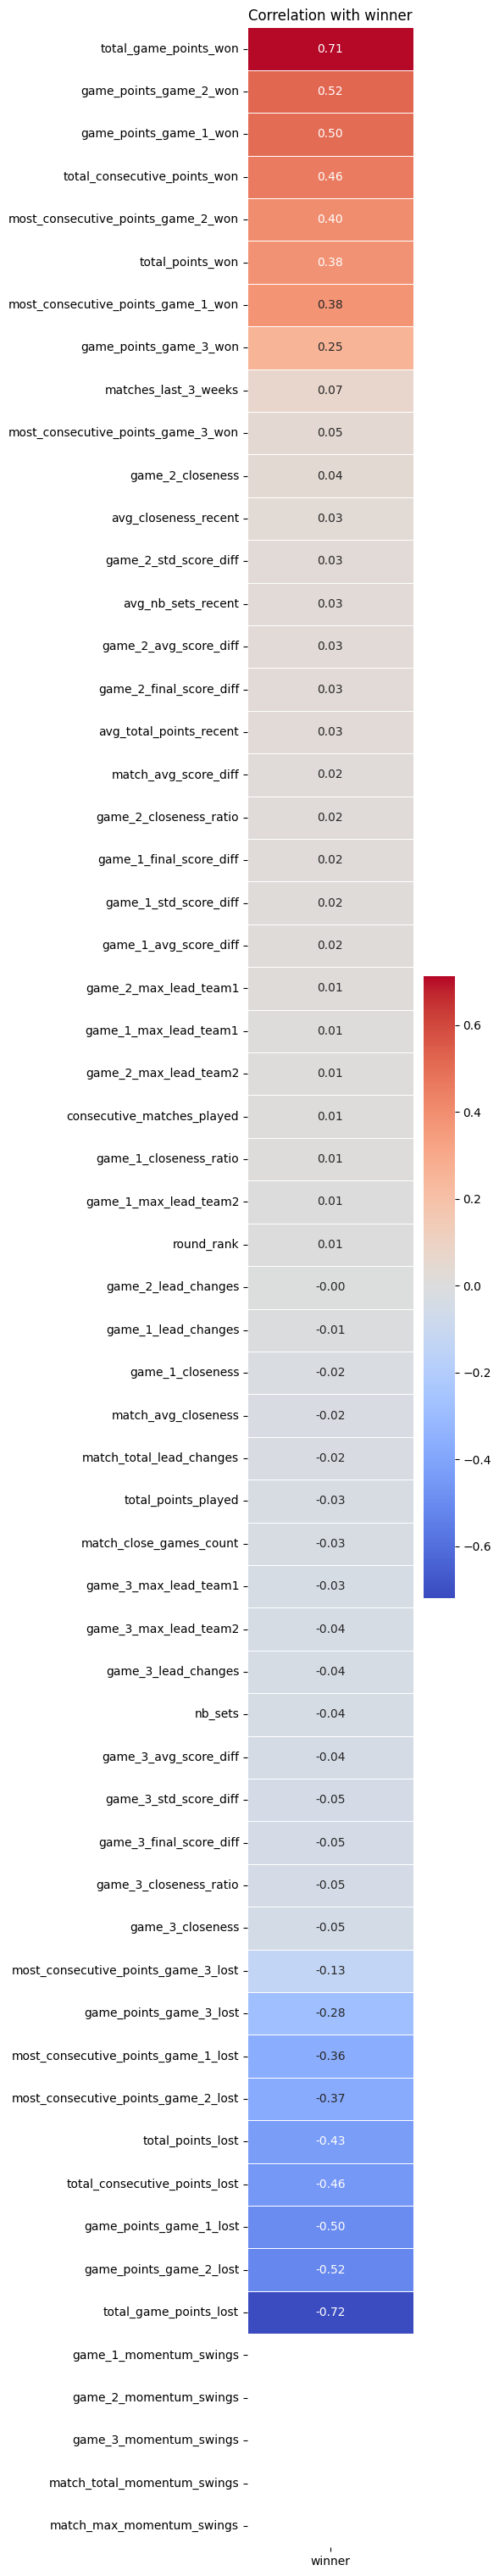

In [22]:
# Select only numeric columns for correlation
numeric_df = cs_df.select_dtypes(include='number')

# Compute correlation with 'winner'
corr_with_winner = numeric_df.corr()[['winner']].drop('winner').sort_values('winner', ascending=False)

# Plot heatmap
plt.figure(figsize=(6, len(corr_with_winner) * 0.5 + 1))
sns.heatmap(
    corr_with_winner,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)
plt.title('Correlation with winner')
plt.tight_layout()
plt.show()

## 9. Modelling - Iteration 1: Remove Leakage and Define Predictors
Before fitting a model, exclude self-selecting outcome variables such as points won and lost.

The remaining feature set focuses on variables that are available before a match starts, so the model tests prediction rather than explanation after the result is already known.

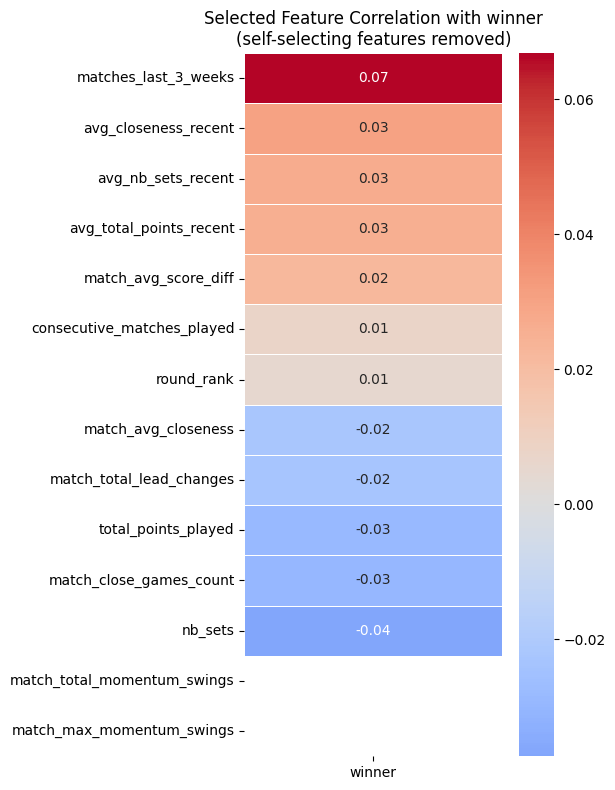


Model dataset shape: (7522, 15)

Correlation values:
                               winner
matches_last_3_weeks         0.066795
avg_closeness_recent         0.030177
avg_nb_sets_recent           0.026891
avg_total_points_recent      0.025701
match_avg_score_diff         0.022309
consecutive_matches_played   0.007389
round_rank                   0.005130
match_avg_closeness         -0.022462
match_total_lead_changes    -0.022853
total_points_played         -0.028849
match_close_games_count     -0.029854
nb_sets                     -0.037372
match_total_momentum_swings       NaN
match_max_momentum_swings         NaN


In [ ]:
# Features to use for Logistic Regression
# Self-selecting features (direct outcomes of winning) are excluded:
#   total_game_points_won/lost, total_points_won/lost, total_consecutive_points_won/lost,
#   game_points_game_X_won/lost, most_consecutive_points_game_X_won/lost
#
# Current-match features (closeness, momentum etc.) describe what happened IN the match —
# they are not available before the match starts, so they are also excluded as predictors.
# They are useful only as OUTCOME descriptors (e.g., how hard was this match?).
#
# What remains are genuine PRE-MATCH indicators:

logreg_features = [
    # Tournament context (known before match)
    'round_rank',
    'nb_sets',           # note: post-match; flag if doing true pre-match prediction

    # Past workload / fatigue (pre-match)
    'matches_last_3_weeks',
    'consecutive_matches_played',
    'avg_total_points_recent',
    'avg_closeness_recent',
    'avg_nb_sets_recent',

    # Current match context features (post-match, useful for analysis... need more work)
    'total_points_played',
    'match_avg_closeness',
    'match_total_momentum_swings',
    'match_total_lead_changes',
    'match_avg_score_diff',
    'match_close_games_count',
    'match_max_momentum_swings',
]

# Filter to only features that actually exist in cs_df
logreg_features = [f for f in logreg_features if f in cs_df.columns]
model_df = cs_df[logreg_features + ['winner']].dropna()

# Show correlation with winner
feature_corr = model_df.corr()[['winner']].drop('winner').sort_values('winner', ascending=False)

plt.figure(figsize=(6, len(logreg_features) * 0.5 + 1))
sns.heatmap(
    feature_corr,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.5
)
plt.title('Selected Feature Correlation with winner\n(self-selecting features removed)')
plt.tight_layout()
plt.show()

print(f"\nModel dataset shape: {model_df.shape}")
print("\nCorrelation values:")
print(feature_corr.to_string())


Logistic regression accuracy: 0.558
Logistic regression ROC AUC: 0.521

Classification report:
              precision    recall  f1-score   support

           0       0.56      0.82      0.66       800
           1       0.56      0.26      0.35       705

    accuracy                           0.56      1505
   macro avg       0.56      0.54      0.51      1505
weighted avg       0.56      0.56      0.52      1505


Confusion matrix:
[[660 140]
 [525 180]]

Feature coefficients:
                   feature  coefficient
      matches_last_3_weeks     0.232434
                round_rank     0.117440
      avg_closeness_recent     0.087912
        avg_nb_sets_recent     0.084612
consecutive_matches_played    -0.058425
   avg_total_points_recent    -0.158058


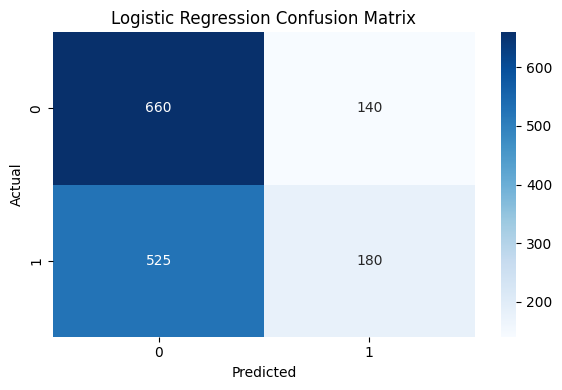

In [24]:
# Use only PRE-MATCH features for prediction.
# This avoids leakage from in-match or post-match outcome variables.
pre_match_features = [
    'round_rank',
    'matches_last_3_weeks',
    'consecutive_matches_played',
    'avg_total_points_recent',
    'avg_closeness_recent',
    'avg_nb_sets_recent',
]

logreg_df = cs_df[pre_match_features + ['winner']].copy()
X = logreg_df[pre_match_features]
y = logreg_df['winner']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, pre_match_features),
])

logreg_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=2000, random_state=42)),
])

logreg_model.fit(X_train, y_train)

y_pred = logreg_model.predict(X_test)
y_prob = logreg_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
cm = confusion_matrix(y_test, y_pred)

print(f'Logistic regression accuracy: {accuracy:.3f}')
print(f'Logistic regression ROC AUC: {roc_auc:.3f}')
print('\nClassification report:')
print(classification_report(y_test, y_pred))
print('\nConfusion matrix:')
print(cm)

coefficients = pd.DataFrame({
    'feature': pre_match_features,
    'coefficient': logreg_model.named_steps['classifier'].coef_[0],
}).sort_values('coefficient', ascending=False)

print('\nFeature coefficients:')
print(coefficients.to_string(index=False))

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


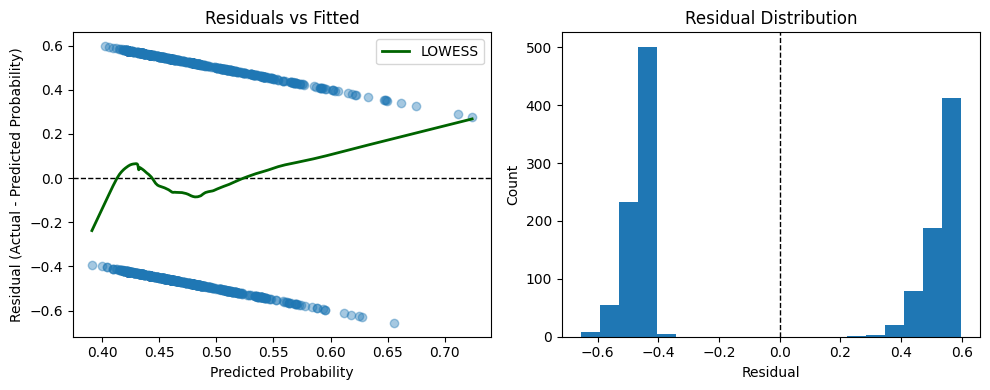

In [ ]:
# Basic residual plots for Logistic Regression (Model 1)
# Residual = actual outcome - predicted probability
from statsmodels.nonparametric.smoothers_lowess import lowess
residuals_1 = y_test.values - y_prob

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Residuals vs predicted probability
axes[0].scatter(y_prob, residuals_1, alpha=0.4)
axes[0].axhline(0, color='black', linestyle='--', linewidth=1)

# LOWESS local regression line
lowess_fit_1 = lowess(residuals_1, y_prob, frac=0.35, return_sorted=True)
axes[0].plot(lowess_fit_1[:, 0], lowess_fit_1[:, 1], color='darkgreen', linewidth=2, label='LOWESS')

axes[0].set_xlabel('Predicted Probability')
axes[0].set_ylabel('Residual (Actual - Predicted Probability)')
axes[0].set_title('Residuals vs Fitted')
axes[0].legend()

# Residual distribution
axes[1].hist(residuals_1, bins=20)
axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution')

plt.tight_layout()
plt.show()

### Residuals Plot Interpretation — Baseline Logistic Regression

The two panels above show the residuals for the baseline logistic regression model, where residual = actual outcome (0 or 1) − predicted probability.

**Residuals vs Fitted (left panel)**
Two horizontal bands are visible: one near +1 (actual winners whose probability was predicted low) and one near −1 (actual non-winners whose probability was predicted high). Because predicted probabilities cluster tightly around 0.5, most residuals fall between roughly −0.5 and +0.5. The lack of any clear slope or curve confirms there is no systematic bias in the predictions — the model is not consistently over- or under-predicting for any region of the probability scale — but equally the near-random scatter reflects the very limited signal in the features.

**Residual Distribution (right panel)**
The histogram shows a bimodal shape with peaks near −0.5 and +0.5, which is expected for a logistic regression applied to a balanced binary target. The symmetry of the two peaks indicates the model treats winners and non-winners similarly, consistent with the near-chance ROC AUC of 0.521.


## 10. Modelling - Iteration 2: Balanced Logistic Regression
The first logistic regression tends to favour the majority class. This second version applies `class_weight='balanced'` to test whether recall for winners improves when the model penalises class imbalance more evenly.

Balanced logistic regression accuracy: 0.526
Balanced logistic regression ROC AUC: 0.521

Classification report:
              precision    recall  f1-score   support

           0       0.55      0.63      0.59       800
           1       0.49      0.40      0.44       705

    accuracy                           0.53      1505
   macro avg       0.52      0.52      0.51      1505
weighted avg       0.52      0.53      0.52      1505


Confusion matrix:
[[507 293]
 [421 284]]

Feature coefficients:
                   feature  coefficient
      matches_last_3_weeks     0.232730
                round_rank     0.116972
      avg_closeness_recent     0.088896
        avg_nb_sets_recent     0.085597
consecutive_matches_played    -0.059082
   avg_total_points_recent    -0.160070


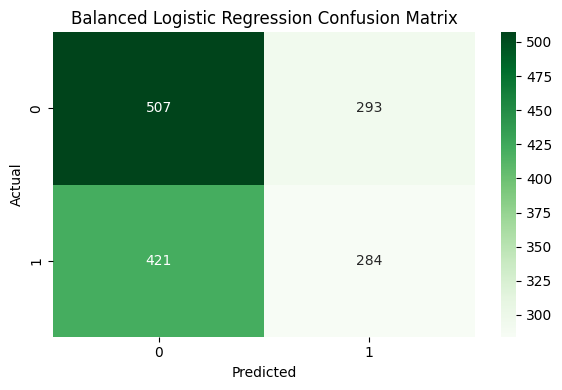

In [26]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

# Balanced logistic regression to compensate for the slight class imbalance
balanced_features = [
    'round_rank',
    'matches_last_3_weeks',
    'consecutive_matches_played',
    'avg_total_points_recent',
    'avg_closeness_recent',
    'avg_nb_sets_recent',
]

balanced_df = cs_df[balanced_features + ['winner']].copy()
X_bal = balanced_df[balanced_features]
y_bal = balanced_df['winner']

X_train_bal, X_test_bal, y_train_bal, y_test_bal = train_test_split(
    X_bal,
    y_bal,
    test_size=0.2,
    random_state=42,
    stratify=y_bal,
)

balanced_preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, balanced_features),
])

balanced_logreg_model = Pipeline([
    ('preprocessor', balanced_preprocessor),
    ('classifier', LogisticRegression(max_iter=2000, random_state=42, class_weight='balanced')),
])

balanced_logreg_model.fit(X_train_bal, y_train_bal)

y_pred_bal = balanced_logreg_model.predict(X_test_bal)
y_prob_bal = balanced_logreg_model.predict_proba(X_test_bal)[:, 1]

balanced_accuracy = accuracy_score(y_test_bal, y_pred_bal)
balanced_roc_auc = roc_auc_score(y_test_bal, y_prob_bal)
balanced_cm = confusion_matrix(y_test_bal, y_pred_bal)

print(f'Balanced logistic regression accuracy: {balanced_accuracy:.3f}')
print(f'Balanced logistic regression ROC AUC: {balanced_roc_auc:.3f}')
print('\nClassification report:')
print(classification_report(y_test_bal, y_pred_bal))
print('\nConfusion matrix:')
print(balanced_cm)

balanced_coefficients = pd.DataFrame({
    'feature': balanced_features,
    'coefficient': balanced_logreg_model.named_steps['classifier'].coef_[0],
}).sort_values('coefficient', ascending=False)

print('\nFeature coefficients:')
print(balanced_coefficients.to_string(index=False))

plt.figure(figsize=(6, 4))
sns.heatmap(balanced_cm, annot=True, fmt='d', cmap='Greens')
plt.title('Balanced Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


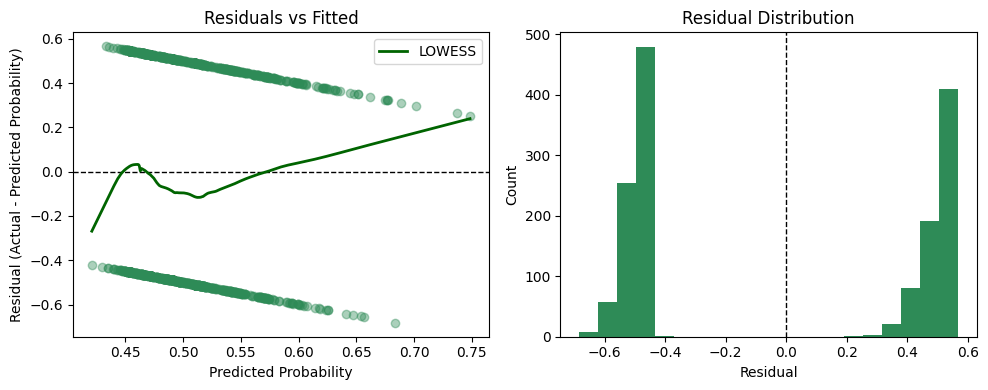

In [27]:
# Basic residual plots for Balanced Logistic Regression (Model 2)
# Residual = actual outcome - predicted probability
from statsmodels.nonparametric.smoothers_lowess import lowess
residuals_bal = y_test_bal.values - y_prob_bal

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Residuals vs predicted probability
axes[0].scatter(y_prob_bal, residuals_bal, alpha=0.4, color='seagreen')
axes[0].axhline(0, color='black', linestyle='--', linewidth=1)

# LOWESS local regression line
lowess_fit_bal = lowess(residuals_bal, y_prob_bal, frac=0.35, return_sorted=True)
axes[0].plot(lowess_fit_bal[:, 0], lowess_fit_bal[:, 1], color='darkgreen', linewidth=2, label='LOWESS')

axes[0].set_xlabel('Predicted Probability')
axes[0].set_ylabel('Residual (Actual - Predicted Probability)')
axes[0].set_title('Residuals vs Fitted')
axes[0].legend()

# Residual distribution
axes[1].hist(residuals_bal, bins=20, color='seagreen')
axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution')

plt.tight_layout()
plt.show()

### Residuals Plot Interpretation — Balanced Logistic Regression

**Residuals vs Fitted (left panel)**
The scatter pattern is broadly similar to the baseline model. Predicted probabilities spread slightly further from 0.5 compared to the baseline, reflecting the model's adjusted decision boundary under balanced class weights. The two horizontal bands of residuals near +1 and −1 remain visible. There is no clear systematic pattern across the fitted range, so the model does not appear to be biased in a particular direction.

**Residual Distribution (right panel)**
The bimodal distribution of residuals is retained, but the two peaks are noticeably more equal in height than in the baseline model. This reflects the class-weight adjustment: the model now makes more positive (winner) predictions, shifting the residual distribution so that the peak near −0.5 (false positives for non-winners) grows while the peak near +0.5 (missed winners) shrinks. This aligns with the improved recall for winners (40% vs 26%) at the cost of precision.

Overall, the residuals of both models confirm that no strong systematic bias is present, but also that the feature set provides very little discriminatory signal regardless of the weighting scheme applied.


## 11. Validation and Player Spot Checks
Use a player-name search to inspect individual records and sanity-check whether transformed fields and engineered features line up with known cases.

In [28]:
substring = 'long chen'

locations = []
for col in cs_df.columns:
    mask = cs_df[col].astype(str).str.contains(substring, case=False, na=False)
    for idx in cs_df[mask].index:
        locations.append((idx, col, cs_df.loc[idx, col]))


print(f"\nSpecific locations of '{substring}':")
for row_idx, col_name, value in locations:
    print(f"Row {row_idx}, Column '{col_name}': {value}")


Specific locations of 'long chen':
Row 121, Column 'player_name': Long Chen
Row 200, Column 'player_name': Long Chen
Row 241, Column 'player_name': Long Chen
Row 243, Column 'player_name': Long Chen
Row 534, Column 'player_name': Long Chen
Row 555, Column 'player_name': Long Chen
Row 564, Column 'player_name': Long Chen
Row 1191, Column 'player_name': Long Chen
Row 1253, Column 'player_name': Long Chen
Row 2021, Column 'player_name': Long Chen
Row 2055, Column 'player_name': Long Chen
Row 2067, Column 'player_name': Long Chen
Row 2107, Column 'player_name': Long Chen
Row 2226, Column 'player_name': Long Chen
Row 2259, Column 'player_name': Long Chen
Row 2554, Column 'player_name': Long Chen
Row 2640, Column 'player_name': Long Chen
Row 2654, Column 'player_name': Long Chen
Row 2666, Column 'player_name': Long Chen
Row 2668, Column 'player_name': Long Chen
Row 2673, Column 'player_name': Long Chen
Row 2872, Column 'player_name': Long Chen
Row 2913, Column 'player_name': Long Chen
Row 2

---

## 12. Summary of Findings

### Research question
> Does prior match load affect a BWF World Tour player's probability of winning their next match?

---

### Data and feature engineering
- 3,761 men's singles matches were processed (2018–2021).
- Tournament round names were mapped to a consistent ordinal rank across all tournament formats.
- Retired matches were resolved by tracing the advancing player to the next round.
- 33 in-match features were engineered from game score progressions, covering closeness, momentum swings, and lead changes per game and across the full match.
- The raw match table was reshaped into 7,522 player-level rows (one per player per match) with a binary `winner` target.
- Rolling pre-match workload features were computed for each row using only matches that occurred before the current match date.

---

### Correlation findings

| Feature | Correlation with winner |
|---|---|
| `matches_last_3_weeks` | +0.07 |
| `consecutive_matches_played` | +0.04 |
| `avg_closeness_recent` | +0.03 |
| `avg_nb_sets_recent` | +0.03 |
| `avg_total_points_recent` | +0.03 |

All pre-match workload features show very weak correlations with the match outcome. In-match features such as total points played and match closeness also show no meaningful association with winning when used in isolation.

---

### Model results

**Iteration 1 — Baseline logistic regression (default class weights)**

| Metric | Value |
|---|---|
| Accuracy | 55.8% |
| ROC AUC | 0.521 |
| Recall for winners | 26% |
| Confusion matrix | 660 correct non-wins, 140 false alarms, 525 missed wins, 180 correct wins |

The model predicts non-wins well but has poor recall for actual match wins. The ROC AUC near 0.5 indicates the feature set carries almost no discriminatory information beyond chance.

**Iteration 2 — Balanced logistic regression (`class_weight='balanced'`)**

| Metric | Value |
|---|---|
| Accuracy | 52.6% |
| ROC AUC | 0.521 |
| Recall for winners | 40% |
| Confusion matrix | 507 correct non-wins, 293 false alarms, 421 missed wins, 284 correct wins |

Applying balanced class weights increases recall for winners from 26% to 40% at the cost of lower overall accuracy. The ROC AUC is unchanged, confirming the improvement is a trade-off in decision threshold behaviour rather than an improvement in the underlying signal.

---

### Residuals analysis

Residuals were computed as actual outcome (0 or 1) minus predicted probability for both models.

**Residuals vs Fitted plots**
Both models produce the same characteristic two-band scatter: one band near +1 (winners whose win probability was predicted low) and one near −1 (non-winners whose win probability was predicted high). Predicted probabilities cluster tightly around 0.5 in both models, reflecting the weak feature signal. No systematic curve or slope is visible across the fitted range, so neither model exhibits directional bias — they are simply uninformative rather than systematically wrong.

**Residual distribution histograms**
Both histograms are bimodal with peaks near −0.5 and +0.5, which is the expected shape for a logistic regression on a near-balanced binary target. In the balanced model, the two peaks become more equal in height as the model makes more positive (winner) predictions, which corresponds to the improved recall for winners. The overall spread of residuals is similar across both models, consistent with the identical ROC AUC of 0.521.

**Key takeaway from residuals:** The residual plots confirm there is no structural misspecification in either model. The issue is feature weakness, not model failure — the selected pre-match workload features simply do not carry enough information to separate winners from non-winners.

---

### Conclusion
The analysis finds no strong evidence that recent match load predicts who wins on the BWF World Tour. The pre-match workload features tested here — volume of recent matches, consecutive match streaks, and recent match intensity — have very weak individual correlations with outcome and contribute little to a logistic regression model.

This is itself a substantive finding. It suggests that elite players in this dataset are able to maintain consistent performance regardless of recent match volume, or that scheduling and recovery practices at the World Tour level mitigate fatigue effects.

**Suggested next steps:**
1. Add player ranking or seeding as a predictor — likely to explain far more variance than load.
2. Include days since last match as a direct rest indicator.
3. Test non-linear models (Random Forest, XGBoost) to capture interaction effects between load variables.
4. Investigate subgroups such as younger versus more experienced players who may respond differently to match load.
